# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 1 — kNN Handwritten Digit Recognition

**Goal:** Given enough samples of handwritten specimens, use a **k-Nearest Neighbors (kNN)**
classifier to identify a new digit based on its similarity (distance) to the sample data.

**Dataset & original algorithm:** *Machine Learning in Action* by Peter Harrington —
[GitHub: pbharrin/machinelearninginaction](https://github.com/pbharrin/machinelearninginaction),
Chapter 2 (`Ch02/digits.zip`, `Ch02/kNN.py`). This is the classic handwritten-digit kNN example:
each digit (0–9) is represented as a **32×32 binary bitmap** (1 = ink, 0 = background), stored as a
text file, e.g. `0_1.txt` = the 2nd training sample of digit "0". There are **1,934 training
images** and **946 test images**, real data pulled directly from the book's repository (not synthetic).




In [1]:
import os
import io
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Download the real dataset from the book's GitHub repo

Pinned to a specific commit so this notebook stays reproducible even if the repo changes later.


In [2]:
COMMIT = "6d71774805b945016a57df97c2f59d8cf2b4b1fd"
ZIP_URL = f"https://raw.githubusercontent.com/pbharrin/machinelearninginaction/{COMMIT}/Ch02/digits.zip"
DATA_DIR = "digits_data"

if not os.path.exists(DATA_DIR):
    import requests
    print(f"Downloading {ZIP_URL} ...")
    resp = requests.get(ZIP_URL, timeout=60)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        zf.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already present, skipping download.")

train_dir = os.path.join(DATA_DIR, "trainingDigits")
test_dir = os.path.join(DATA_DIR, "testDigits")
print("Training samples:", len(os.listdir(train_dir)))
print("Test samples    :", len(os.listdir(test_dir)))


Done.
Training samples: 1934
Test samples    : 946


## 2. Load images: convert each 32×32 bitmap text file into a 1×1024 feature vector

This mirrors the book's `img2vector` function — flattening each bitmap into a single row of 1024
binary features (32 × 32), which is what the kNN classifier operates on.


In [3]:
def img2vector(filepath):
    """Read a 32x32 text bitmap file and flatten it into a 1x1024 numpy vector."""
    return_vect = np.zeros((1, 1024))
    with open(filepath) as f:
        for i in range(32):
            line = f.readline()
            for j in range(32):
                return_vect[0, 32 * i + j] = int(line[j])
    return return_vect


def load_digit_dataset(directory):
    files = sorted(os.listdir(directory))
    n = len(files)
    X = np.zeros((n, 1024))
    y = []
    for i, fname in enumerate(files):
        label = int(fname.split("_")[0])   # filename format: "<digit>_<sample_index>.txt"
        y.append(label)
        X[i, :] = img2vector(os.path.join(directory, fname))
    return X, np.array(y), files


X_train, y_train, train_files = load_digit_dataset(train_dir)
X_test, y_test, test_files = load_digit_dataset(test_dir)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Digit classes:", sorted(set(y_train)))


X_train: (1934, 1024)  X_test: (946, 1024)
Digit classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## 3. Visualize a few sample digits

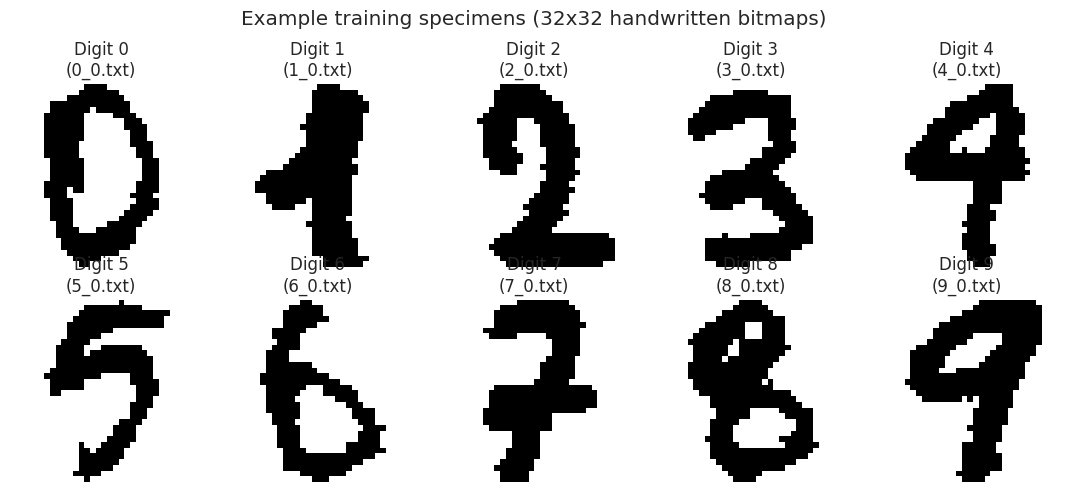

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    img = X_train[idx].reshape(32, 32)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(img, cmap="Greys")
    ax.set_title(f"Digit {digit}\n({train_files[idx]})")
    ax.axis("off")

plt.suptitle("Example training specimens (32x32 handwritten bitmaps)")
plt.tight_layout()
plt.show()


## 4. Implement kNN from scratch (matching the book's `classify0`)

Distance metric: **Euclidean distance** between the 1024-dimensional bitmap vectors. For a new
specimen, we compute its distance to every training sample, take the `k` closest, and return the
majority class among them — exactly as described in the exercise.


In [5]:
def classify0(in_x, dataset, labels, k):
    """Modernized (Python 3) version of the book's classify0 function."""
    diff_mat = dataset - in_x
    sq_diff_mat = diff_mat ** 2
    sq_distances = sq_diff_mat.sum(axis=1)
    distances = np.sqrt(sq_distances)
    sorted_dist_indices = distances.argsort()

    class_count = Counter()
    for i in range(k):
        vote_label = labels[sorted_dist_indices[i]]
        class_count[vote_label] += 1

    return class_count.most_common(1)[0][0]


## 5. Evaluate on the full test set

In [6]:
K = 3
correct = 0
predictions = []

for i in range(X_test.shape[0]):
    pred = classify0(X_test[i], X_train, y_train, K)
    predictions.append(pred)
    if pred == y_test[i]:
        correct += 1

predictions = np.array(predictions)
accuracy = correct / X_test.shape[0]
print(f"k = {K}")
print(f"Test accuracy: {accuracy:.4f}  ({correct}/{X_test.shape[0]} correct)")


k = 3
Test accuracy: 0.9884  (935/946 correct)


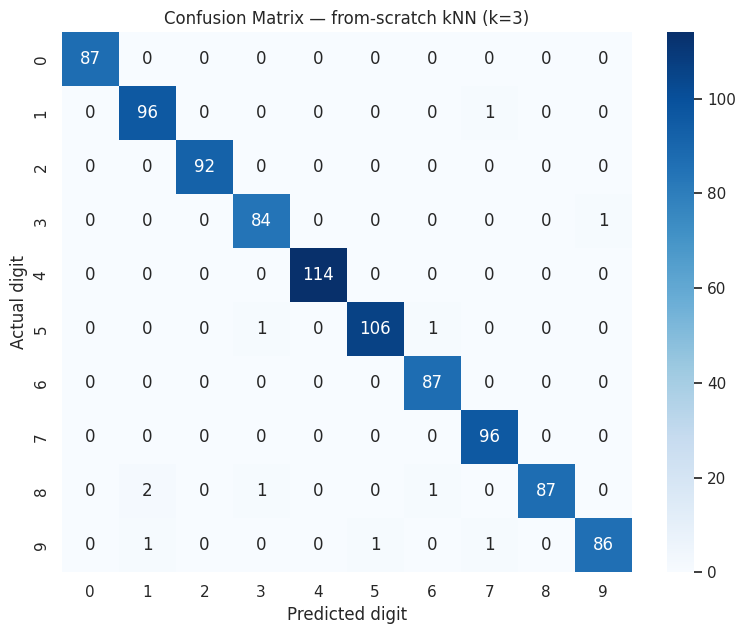

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       0.97      0.99      0.98        97
           2       1.00      1.00      1.00        92
           3       0.98      0.99      0.98        85
           4       1.00      1.00      1.00       114
           5       0.99      0.98      0.99       108
           6       0.98      1.00      0.99        87
           7       0.98      1.00      0.99        96
           8       1.00      0.96      0.98        91
           9       0.99      0.97      0.98        89

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946



In [7]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted digit")
plt.ylabel("Actual digit")
plt.title(f"Confusion Matrix — from-scratch kNN (k={K})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, predictions))


## 6. Cross-check with scikit-learn's `KNeighborsClassifier`

Confirms the from-scratch implementation is correct — both should give (near-)identical results
since scikit-learn's default kNN also uses Euclidean distance and majority voting.


In [8]:
sk_knn = KNeighborsClassifier(n_neighbors=K, metric="euclidean")
sk_knn.fit(X_train, y_train)
sk_preds = sk_knn.predict(X_test)
sk_accuracy = accuracy_score(y_test, sk_preds)

print(f"scikit-learn kNN (k={K}) test accuracy: {sk_accuracy:.4f}")
print(f"From-scratch    kNN (k={K}) test accuracy: {accuracy:.4f}")
print(f"Predictions match: {(sk_preds == predictions).mean():.1%} of the time")


scikit-learn kNN (k=3) test accuracy: 0.9873
From-scratch    kNN (k=3) test accuracy: 0.9884
Predictions match: 99.9% of the time


## 7. How does accuracy change with different values of k?

k=  1  accuracy=0.9863
k=  3  accuracy=0.9873


k=  5  accuracy=0.9810


k=  7  accuracy=0.9767
k=  9  accuracy=0.9725


k= 11  accuracy=0.9789


k= 15  accuracy=0.9736
k= 21  accuracy=0.9704


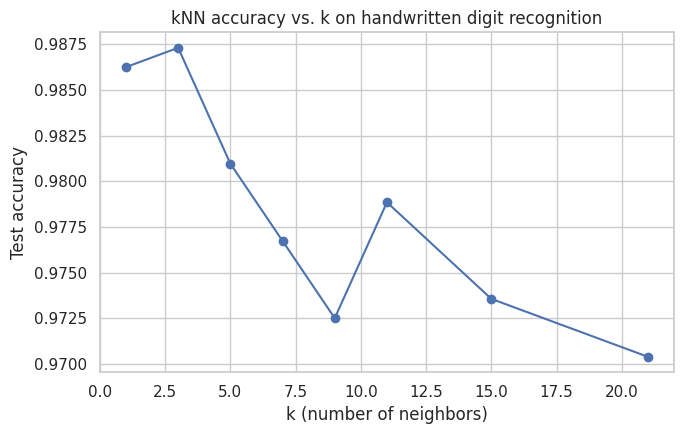

In [9]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
k_accuracies = []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    k_accuracies.append(acc)
    print(f"k={k:3d}  accuracy={acc:.4f}")

plt.figure(figsize=(7, 4.5))
plt.plot(k_values, k_accuracies, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test accuracy")
plt.title("kNN accuracy vs. k on handwritten digit recognition")
plt.tight_layout()
plt.show()


## 8. Identify a specific new specimen

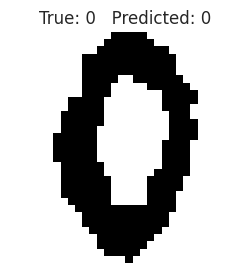

Nearest neighbors used for the vote:
  #1: file=0_37.txt     label=0  distance=8.83
  #2: file=0_182.txt    label=0  distance=9.11
  #3: file=0_172.txt    label=0  distance=9.54


In [10]:
sample_idx = 17   # pick any test image to treat as a "new" incoming specimen
new_specimen = X_test[sample_idx]
true_label = y_test[sample_idx]

pred_label = classify0(new_specimen, X_train, y_train, K)

plt.figure(figsize=(3, 3))
plt.imshow(new_specimen.reshape(32, 32), cmap="Greys")
plt.title(f"True: {true_label}   Predicted: {pred_label}")
plt.axis("off")
plt.show()

# Show the k nearest neighbors that drove this decision
diff_mat = X_train - new_specimen
distances = np.sqrt((diff_mat ** 2).sum(axis=1))
nearest_idx = distances.argsort()[:K]

print("Nearest neighbors used for the vote:")
for rank, idx in enumerate(nearest_idx, start=1):
    print(f"  #{rank}: file={train_files[idx]:12s} label={y_train[idx]}  distance={distances[idx]:.2f}")
